## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## **Load Dataset**

In [2]:
df_interactions = pd.read_csv("../data/RAW_interactions.csv")

df_interactions.head()

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


## **Exploratory Data Analysis on ratings**

1. Some users did not rate, resulting in 0 ratings, even though some of the ratings are positive/ negative.

2. The user ratings are subjective, and despite giving a very good review, the user gave a subpar rating score.

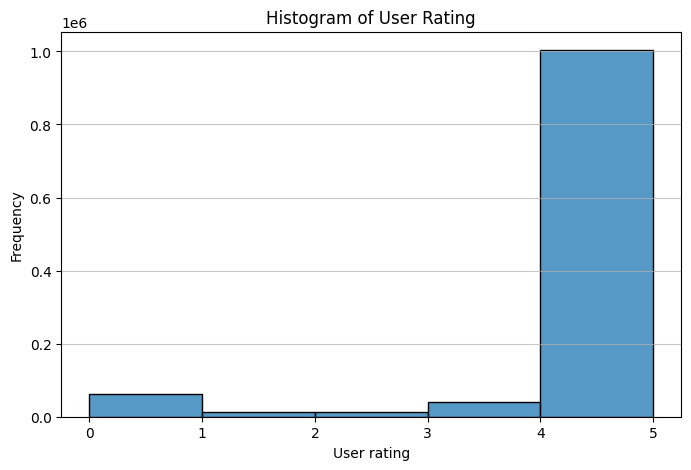

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(df_interactions['rating'], bins=5)
plt.xlabel('User rating')
plt.ylabel('Frequency')
plt.title('Histogram of User Rating')
plt.grid(axis='y', alpha=0.7)
plt.show()

### 0 Ratings

In [4]:
df_interactions[df_interactions['rating']==0]

,user_id,recipe_id,date,rating,review
6,124416,120345,2011-08-06,0,"Just an observation, so I will not rate. I fo..."
12,468945,134728,2008-02-20,0,Made my own buttermilk w/ vinegar and milk. U...
23,681408,225241,2008-03-14,0,This is a very good recipe. We also want to c...
39,2002068522,29093,2018-03-26,0,i made it and it was amazing
56,980899,79222,2010-10-18,0,"I used half cream and half 1% milk, added anot..."
...,...,...,...,...,...
1132318,1197076,190261,2010-03-08,0,Delicious ! I tweeked the recipe a bit>>substi...
1132323,2405600,290157,2014-11-10,0,Just added this mix to a homemade beef &amp; s...
1132325,2000650711,290157,2017-04-10,0,Would this make a good hamburger patty seasoning?
1132361,102526,54493,2007-04-26,0,I am not going to rate this because I did have...


### Subjective ratings

In [5]:
df_interactions[df_interactions['rating'] == 4]

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
5,52282,120345,2005-05-21,4,very very sweet. after i waited the 2 days i b...
8,76535,134728,2005-09-02,4,Very good!
16,68960,200236,2006-12-19,4,We really enjoyed this and so did both my youn...
...,...,...,...,...,...
1132332,233495,190698,2007-07-05,4,I make something like this with blackberry pre...
1132344,58104,249924,2008-04-14,4,I used Recipe #185431 for the bread to hold th...
1132350,417131,241491,2007-09-05,4,I made this over the weekend and changed it up...
1132352,1269180,257796,2011-08-07,4,Very tender and juicy - had trouble getting t...


## **Sentiment Analysis**

Applied a pretrained sentiment analysis model, VADER (Fast and efficient but doesn't capture complex linguistic nuances or sarcasm), to analyse the reviews and obtain sentiment scores. A more advanced model, such as BERT, can be utilised once we upgrade to Colab Pro for enhanced computational resources.

In [6]:
import nltk 
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer # type: ignore

analyzer = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/madhupolluru/nltk_data...


Weighing sentiment score and ratings based on conditions:

*   If there is no review following a rating:
If no rating is present, assign a default rating of 3.
Otherwise, use the existing rating as is.
*   If conflict (sentiment score and ratings are not similar):
Weigh sentiment score less because VADER cannot capture the nuance of food reviews.
Otherwise, weigh sentiment score more.


In [7]:
def weighted_sentiment(review, rating):

  if not isinstance(review, str):
    if rating == 0:
      return 3 #if no review and rating of 0, then return 3
    return rating  # elif there is no review, then return actual rating

  va = analyzer.polarity_scores(review)['compound']

  avg_sentiment = va

  if avg_sentiment >= 0.7:
    computed_score = 5
  elif avg_sentiment > 0.4:
    computed_score = 4
  elif avg_sentiment > -0.4:
    computed_score = 3
  elif avg_sentiment > -0.7:
    computed_score = 2
  else:
    computed_score = 1

  #if conflict between avg_sentiment and actual sentiment

  if rating == 0 and rating == 0:
    weighted_score = 3
  elif rating == 0:
    weighted_score = computed_score
  elif (rating > 3 and computed_score < 3) or (rating<3 and computed_score >3):
    weighted_score = computed_score * 0.3 + rating * 0.7
  else:
    weighted_score = computed_score * 0.6 + rating * 0.4

  return weighted_score

In [8]:
# Apply the model to review to get sentiment score
df_interactions['weighted_score'] = df_interactions.apply(lambda x: weighted_sentiment(x['review'], x['rating']), axis=1)

df_interactions.head()

,user_id,recipe_id,date,rating,review,weighted_score
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,4.6
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",5.0
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,4.6
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,4.4
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",3.8


In [9]:
# Write the file into csv for faster accessing next time with new `weighted_score` column
df_interactions.to_csv("../data/df_interactions_with_ratings.csv", index=False)

In [10]:
# use this to load the df_interactions with rating
df_interactions = pd.read_csv("../data/df_interactions_with_ratings.csv")

df_interactions

,user_id,recipe_id,date,rating,review,weighted_score
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...,4.6
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall...",5.0
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...,4.6
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...,4.4
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin...",3.8
...,...,...,...,...,...,...
1132362,116593,72730,2003-12-09,0,Another approach is to start making sauce with...,3.0
1132363,583662,386618,2009-09-29,5,These were so delicious! My husband and I tru...,5.0
1132364,157126,78003,2008-06-23,5,WOW! Sometimes I don't take the time to rate ...,5.0
1132365,53932,78003,2009-01-11,4,Very good! I used regular port as well. The ...,4.6


In [11]:
pd.options.display.float_format = '{:.3f}'.format

df_interactions.describe()

,user_id,recipe_id,rating,weighted_score
count,1132367.000,1132367.000,1132367.000,1132367.000
mean,138429067.431,160897.208,4.411,4.581
std,501426863.684,130398.720,1.265,0.691
min,1533.000,38.000,0.000,1.000
25%,135470.000,54257.000,4.000,4.400
50%,330937.000,120547.000,5.000,5.000
75%,804550.000,243852.000,5.000,5.000
max,2002372706.000,537716.000,5.000,5.000


In [12]:
df_interactions['weighted_score'].median()

5.0

### New distribution of ratings

After weighing, visualize their distribution: Left skewed because both sentiment score (from reviews) and ratings are left skewed

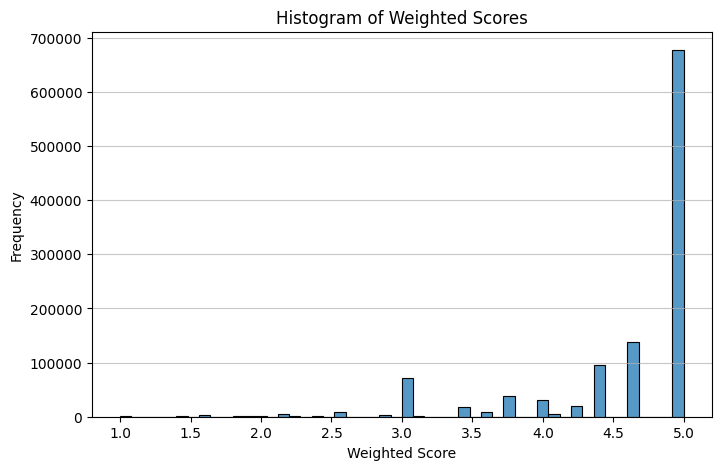

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df_interactions['weighted_score'], bins=50)
plt.xlabel('Weighted Score')
plt.ylabel('Frequency')
plt.title('Histogram of Weighted Scores')
plt.grid(axis='y', alpha=0.7)
plt.show()